In [2]:
import cv2
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt

In [3]:
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tensorflow.__version__

2026-06-08 18:41:54.545225: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 18:41:54.592302: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 18:41:54.592961: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 18:41:55.372389: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


'2.12.1'

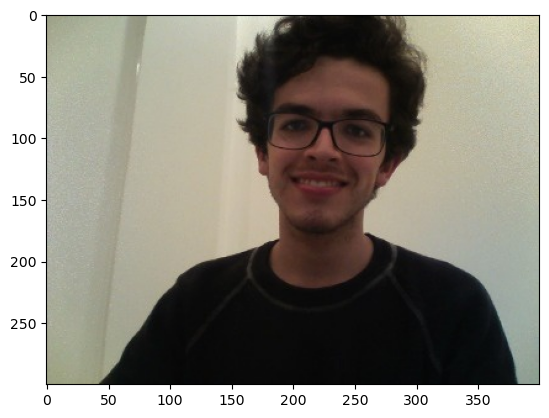

In [4]:
# caminho para a imagem a ser carregada
img_path = '../Material/Material/testes/teste_gabriel.png'
img = cv2.imread(img_path)

# tive que alterar o tipo da cor para mostrar no pyplot inves de usar a lib padrao do cv2 que estava dando erro
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# mostrando a imagem
plt.imshow(img_rgb)
plt.show()

In [5]:
# modelo para detectar faces
cascade_faces = '../Material/Material/haarcascade_frontalface_default.xml'
# caminho para o modelo treinado para identificar emoções
path_model = '../Material/Material/modelo_01_expressoes.h5'

# carregando os objetos de reconhecimento de faces e emoções com os modelos
face_detection = cv2.CascadeClassifier(cascade_faces)
emotion_class = load_model(path_model, compile = False)

# expressoes faciais
exp = ['Raiva', 'Nojo', 'Medo', 'Feliz', 'Triste', 'Surpreso', 'Neutro']

In [6]:
# copiando a imagem para detectar a face
original = img.copy()

original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# fazendo a detecção de faces
faces = face_detection.detectMultiScale(original,
                                        scaleFactor=1.1,
                                        minNeighbors=3,
                                        minSize=(20,20))

In [7]:
# vendo a dimensão da face reconhecida
faces

array([[162,  40, 128, 128]], dtype=int32)

In [8]:
# quantidade de faces detectadas
len(faces), faces.shape

(1, (1, 4))

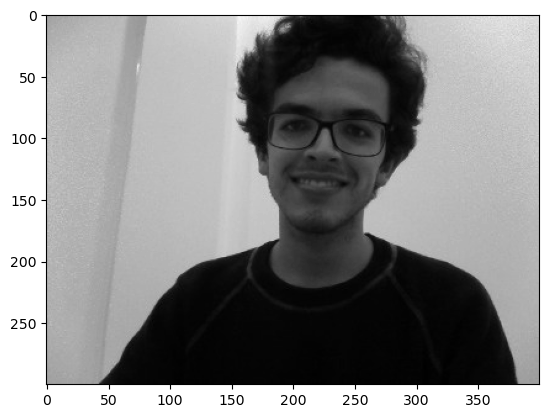

In [9]:
# convertendo para cinza 
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.show()


In [10]:
# pegando a região de interesse (valores tirados do resultado de 'faces')
roi = gray[40: 40 + 128, 162: 162 + 128]

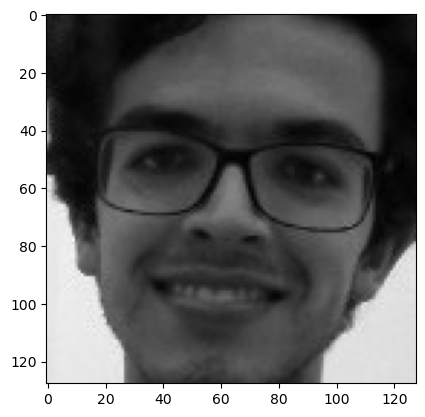

In [11]:
# mostrando a area de interesse
plt.imshow(roi, cmap='gray')
plt.show()

In [12]:
# valores dos pixels
roi

array([[ 39,  37,  28, ...,  25,  29,  34],
       [ 34,  32,  25, ...,  24,  24,  29],
       [ 31,  33,  30, ...,  23,  22,  26],
       ...,
       [184, 185, 186, ..., 180, 181, 181],
       [184, 185, 186, ..., 179, 181, 180],
       [184, 185, 187, ..., 180, 181, 180]], dtype=uint8)

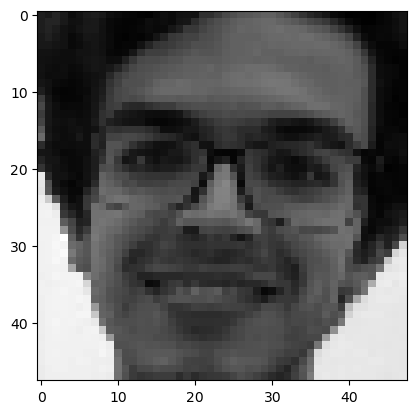

In [13]:
# reduzindo o tamanho da imagem
roi = cv2.resize(roi, (48, 48))
plt.imshow(roi, cmap='gray')
plt.show()

In [14]:
# tipo do dado
roi.dtype

dtype('uint8')

In [15]:
# convertendo para float
roi = roi.astype('float')
roi.dtype

dtype('float64')

In [16]:
# normalização
roi = roi / 255
roi

array([[0.12941176, 0.11372549, 0.14901961, ..., 0.0627451 , 0.08627451,
        0.09803922],
       [0.1254902 , 0.14509804, 0.14509804, ..., 0.0627451 , 0.07843137,
        0.09803922],
       [0.1254902 , 0.14117647, 0.12156863, ..., 0.06666667, 0.08235294,
        0.09803922],
       ...,
       [0.72941176, 0.74117647, 0.74117647, ..., 0.70980392, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.74117647, ..., 0.70588235, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.7372549 , ..., 0.70196078, 0.70588235,
        0.70980392]])

In [17]:
# transformando em 3 dimensões
roi = img_to_array(roi)
roi

array([[[0.12941177],
        [0.11372549],
        [0.14901961],
        ...,
        [0.0627451 ],
        [0.08627451],
        [0.09803922]],

       [[0.1254902 ],
        [0.14509805],
        [0.14509805],
        ...,
        [0.0627451 ],
        [0.07843138],
        [0.09803922]],

       [[0.1254902 ],
        [0.14117648],
        [0.12156863],
        ...,
        [0.06666667],
        [0.08235294],
        [0.09803922]],

       ...,

       [[0.7294118 ],
        [0.7411765 ],
        [0.7411765 ],
        ...,
        [0.70980394],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7411765 ],
        ...,
        [0.7058824 ],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7372549 ],
        ...,
        [0.7019608 ],
        [0.7058824 ],
        [0.70980394]]], dtype=float32)

In [18]:
roi.shape

(48, 48, 1)

In [19]:
# adicionando mais uma dimensão para poder utilizar a imagem no treinamento
roi = np.expand_dims(roi, axis = 0)
roi.shape

(1, 48, 48, 1)

In [20]:
# fazendo uma previsao
preds = emotion_class.predict(roi)[0]
preds

1/1 [==============================] - 0s 183ms/step


array([1.6802111e-05, 5.7679665e-09, 1.1206568e-05, 9.9066460e-01,
       1.8033754e-05, 1.8518280e-05, 9.2708124e-03], dtype=float32)

In [21]:
len(preds)

7

In [22]:
# vendo a maior probabilidade
emotion_probability = np.max(preds)
emotion_probability

0.9906646

In [23]:
# vendo o index que tem o maior valor
preds.argmax()

3

In [24]:
# vendo a resposta da previsao
label = exp[preds.argmax()]
label

'Feliz'

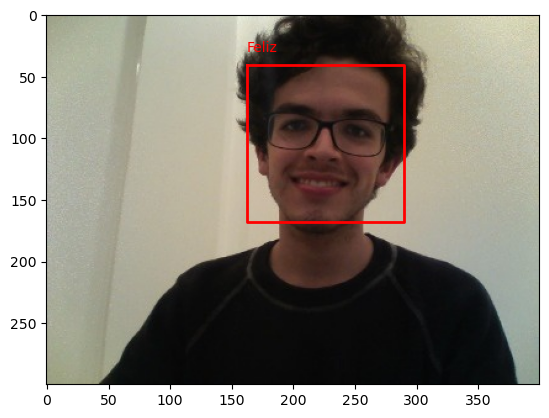

In [25]:
# mostra a imagem
plt.imshow(original_rgb)

# coordenadas das linhas para fechar o retangulo
x_coords = [162, 162 + 128, 162 + 128, 162, 162]
y_coords = [40, 40, 40 + 128, 40 + 128, 40]
# desenhando o quadrado
plt.plot(x_coords, y_coords, color='red', linewidth=2)
# coloando o texto
plt.text(162, 30, label, color='red')
plt.show()

In [26]:
# criando variaveis para as barras de probabilidades
probabilities = np.ones((250,300,3), dtype='uint8') * 255

In [28]:
# dessa vez fiz o codigo exatamente da forma que esta no video, mas isso significa que nao consigo exibir
# pelo notebook, pois o cv2 por padrao exibe a imagem direto na imagem da tela

cv2.imshow('', original)
if len(faces) == 1:
    for(i, (emotion, prob)) in enumerate(zip(exp, preds)):
        # print(i, emotion, prob)
        # texto da barrinha
        text = "{}: {:.2f}%".format(emotion, prob*100)
        # peso da barrinha
        w = int(prob * 300)
        cv2.rectangle(probabilities, (7, (i * 35) + 5), (w, (i * 35) + 35), (200, 250, 20), -1)
        cv2.putText(probabilities, text, (10, (i * 35) + 23), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)
cv2.imshow('', probabilities)